# Data extraction
We have downloaded the dataset with demographic information for every one of the 8132 municipalities in Spain from the MITECO (Spanish Ministry for the Ecological Transition and the Demographic Challenge) website. We also have downloaded the electoral results for the july 2023 and november 2019 general elections in Spain from the Spanish Ministry for the Interior, which are in a Excel format.

The implementation of most of the funcions for data extraction are in the `src/data_extraction.py` file. 

In [23]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

%load_ext autoreload
%autoreload 2

from src import data_extraction as de

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## `load_miteco` Function

The `load_miteco` function extracts the demographic data from the MITECO dataset and merges it in a GeoDataFrame with the geographical data of the municipalities in Spain. We have the following data:

### Geographical Identifiers
- `ccaa`: Autonomous community where the municipality is located
- `cod_ccaa`: Code of the autonomous community
- `cod_nut1`: Eurostats NUTS1 code (groups of autonomous communities)
- `cod_nut2`: Eurostats NUTS2 code (autonomous communities)
- `cod_nut3`: Eurostats NUTS3 code (provinces)
- `cod_prov`: Province code
- `codmun_ine`: Code of the municipality within its province
- `natcode`: National code of the municipality from the IGE (Instituto Geográfico Español)
- `nombre`: Name of the municipality
- `provincia`: Province where the municipality is located

### Demographic Variables
- `afi_1000`: Number of people affiliated to social security per 1000 inhabitants
- `dens_pob`: Population density (inhabitants per km²)
- `edad_media`: Median age of the population
- `pob_14`: Population in 2014
- `pob_14_23`: Variation in population between 2014 and 2023
- `pob_23`: Population in 2023
- `pob_esup16`: Share or count of the population older than 16 with higher education (university studies or equivalent)
- `pob_npum`: Share of the population living in the municipality in which they were born
- `porc_pob65`: Percentage of the population aged 65 years or older
- `porc_pob_e`: Percentage of foreign population living in the municipality
- `paro_1000`: Number of unemployed people per 1000 inhabitants
- `rat_mascul`: Masculinity ratio (defined as the number of men per 100 women)
- `rta_nt_med`: Mean Net Income (Renta Neta Media) of the municipality

In [24]:
gdf_miteco = de.load_miteco()
print(gdf_miteco.columns)
gdf_miteco

Index(['objectid', 'natcode', 'nombre', 'cod_nut1', 'cod_nut2', 'cod_nut3',
       'codmun_ine', 'ccaa', 'cod_ccaa', 'cod_pro', 'provincia', 'pob_npmun',
       'geometry', 'pob_23', 'dens_pob', 'edad_media', 'afi_1000', 'paro_1000',
       'porc_pob65', 'pob_esup16', 'porc_pob_e', 'rat_mascul', 'rta_nt_med',
       'pob_14', 'pob_14_23'],
      dtype='str')


,objectid,natcode,nombre,cod_nut1,cod_nut2,cod_nut3,codmun_ine,ccaa,cod_ccaa,cod_pro,...,edad_media,afi_1000,paro_1000,porc_pob65,pob_esup16,porc_pob_e,rat_mascul,rta_nt_med,pob_14,pob_14_23
0,7732,34160101001,Alegría-Dulantzi,ES2,ES21,ES211,01001,País Vasco-Euskadi,16,01,...,40.54,322.377960,78.298695,12.162162,42.332066,10.472973,107.172702,36393,2925,1.709402
1,7733,34160101002,Amurrio,ES2,ES21,ES211,01002,País Vasco-Euskadi,16,01,...,45.63,593.042435,108.861898,22.847972,38.223140,6.818403,99.131106,36362,10239,0.722727
2,7737,34160101003,Aramaio,ES2,ES21,ES211,01003,País Vasco-Euskadi,16,01,...,46.73,230.283912,4.206099,23.899371,49.760766,2.585604,108.124077,48487,1478,-4.668471
3,7738,34160101004,Artziniega,ES2,ES21,ES211,01004,País Vasco-Euskadi,16,01,...,43.76,330.057330,70.434070,18.784530,41.282565,5.414365,96.145610,33088,1818,0.770077
4,7734,34160101006,Armiñón,ES2,ES21,ES211,01006,País Vasco-Euskadi,16,01,...,43.73,843.023256,75.581395,14.468085,37.878788,5.106383,107.142857,32914,250,-7.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8126,1737,34025050901,Biel,ES2,ES24,ES243,50901,Aragón,02,50,...,56.63,330.357143,53.571429,37.058824,29.090909,14.705882,160.937500,28950,157,6.369427
8127,1733,34025050902,Marracos,ES2,ES24,ES243,50902,Aragón,02,50,...,56.13,152.542373,0.000000,35.164835,42.857143,0.000000,107.142857,28226,97,-10.309278
8128,1734,34025050903,Villamayor de Gállego,ES2,ES24,ES243,50903,Aragón,02,50,...,45.98,378.104410,49.670552,22.072869,31.265207,5.199859,103.118356,37009,2820,1.631206
8129,8130,34185151001,Ceuta,ES6,ES63,ES630,51001,Ciudad Autónoma de Ceuta,18,51,...,38.56,393.311141,170.032944,12.502857,24.343156,5.907335,101.820391,39330,84963,-2.264515


In [25]:
# Drop geometry (keep only tabular data) and Save to Excel
gdf_miteco.drop(columns='geometry').to_excel(f'01_data_miteco.xlsx', index=False)

## `load_infoelectoral` Function

The `load_infoelectoral` function extracts the electoral data from the Infoelectoral .xlsx files for the july 2023 and november 2019 general elections in Spain. The data is extracted for the following parties: PP, PSOE, VOX, SUMAR (for 2023) and PODEMOS-IU (for 2019). The function returns a DataFrame containing the combined data from all Infoelectoral .xlsx files.

In [26]:
df_infoelectoral = de.load_infoelectoral()
print(df_infoelectoral.columns)
df_infoelectoral

Index(['codmun_ine', 'Total censo electoral_2023', 'PP_2023', 'PSOE_2023',
       'VOX_2023', 'SUMAR_2023', 'Total censo electoral_2019', 'PP_2019',
       'PSOE_2019', 'VOX_2019', 'PODEMOS-IU_2019'],
      dtype='str')


,codmun_ine,Total censo electoral_2023,PP_2023,PSOE_2023,VOX_2023,SUMAR_2023,Total censo electoral_2019,PP_2019,PSOE_2019,VOX_2019,PODEMOS-IU_2019
0,01001,2090,141,368,65,168,2020,114,284,54,249
1,01002,7897,386,1290,132,573,8014,338,930,154,866
2,01003,1150,2,55,5,68,1166,3,26,5,78
3,01004,1398,103,196,33,110,1357,84,108,33,147
4,01006,185,31,28,15,19,174,21,20,18,28
...,...,...,...,...,...,...,...,...,...,...,...
8126,50901,144,46,36,19,17,133,18,33,21,8
8127,50902,82,37,20,9,0,77,29,15,10,3
8128,50903,2308,533,435,331,311,2268,323,433,339,248
8129,51001,60335,12887,11299,7742,812,59820,7407,10405,11734,1287


In [27]:
df_infoelectoral.to_excel(f'01_data_infoelectoral.xlsx', index=False)

## `extract_data` Function

The `extract_data` function combines the demographic data from the MITECO dataset and the electoral data from the Infoelectoral .xlsx files. It merges the two datasets based on the municipality codes and returns a single GeoDataFrame that contains both demographic and electoral information for each municipality in Spain.

In [28]:
gdf = de.extract_data()
print(gdf.columns)
gdf

Index(['objectid', 'natcode', 'nombre', 'cod_nut1', 'cod_nut2', 'cod_nut3',
       'codmun_ine', 'ccaa', 'cod_ccaa', 'cod_pro', 'provincia', 'pob_npmun',
       'geometry', 'pob_23', 'dens_pob', 'edad_media', 'afi_1000', 'paro_1000',
       'porc_pob65', 'pob_esup16', 'porc_pob_e', 'rat_mascul', 'rta_nt_med',
       'pob_14', 'pob_14_23', 'Total censo electoral_2023', 'PP_2023',
       'PSOE_2023', 'VOX_2023', 'SUMAR_2023', 'Total censo electoral_2019',
       'PP_2019', 'PSOE_2019', 'VOX_2019', 'PODEMOS-IU_2019'],
      dtype='str')


,objectid,natcode,nombre,cod_nut1,cod_nut2,cod_nut3,codmun_ine,ccaa,cod_ccaa,cod_pro,...,Total censo electoral_2023,PP_2023,PSOE_2023,VOX_2023,SUMAR_2023,Total censo electoral_2019,PP_2019,PSOE_2019,VOX_2019,PODEMOS-IU_2019
0,7732,34160101001,Alegría-Dulantzi,ES2,ES21,ES211,01001,País Vasco-Euskadi,16,01,...,2090,141,368,65,168,2020,114,284,54,249
1,7733,34160101002,Amurrio,ES2,ES21,ES211,01002,País Vasco-Euskadi,16,01,...,7897,386,1290,132,573,8014,338,930,154,866
2,7737,34160101003,Aramaio,ES2,ES21,ES211,01003,País Vasco-Euskadi,16,01,...,1150,2,55,5,68,1166,3,26,5,78
3,7738,34160101004,Artziniega,ES2,ES21,ES211,01004,País Vasco-Euskadi,16,01,...,1398,103,196,33,110,1357,84,108,33,147
4,7734,34160101006,Armiñón,ES2,ES21,ES211,01006,País Vasco-Euskadi,16,01,...,185,31,28,15,19,174,21,20,18,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8126,1737,34025050901,Biel,ES2,ES24,ES243,50901,Aragón,02,50,...,144,46,36,19,17,133,18,33,21,8
8127,1733,34025050902,Marracos,ES2,ES24,ES243,50902,Aragón,02,50,...,82,37,20,9,0,77,29,15,10,3
8128,1734,34025050903,Villamayor de Gállego,ES2,ES24,ES243,50903,Aragón,02,50,...,2308,533,435,331,311,2268,323,433,339,248
8129,8130,34185151001,Ceuta,ES6,ES63,ES630,51001,Ciudad Autónoma de Ceuta,18,51,...,60335,12887,11299,7742,812,59820,7407,10405,11734,1287


In [ ]:
gdf.drop(columns='geometry').to_excel(f'01_data_combined.xlsx', index=False)

In [ ]:
#Sample 1000 rows to keep it fast
# Save the map as an HTML
m = gdf.explore()
m.save('01_map_output.html')
print("Map saved to 01_map_output.html - open it in your browser (Note: it is heavy, it will consume a lot of memory and may be slow to load)")

Map saved to 01_map_output.html - open it in your browser


In [45]:
# Using Lonboard (Fastest for large data)
from lonboard import viz
viz(gdf)

ModuleNotFoundError: No module named 'lonboard'

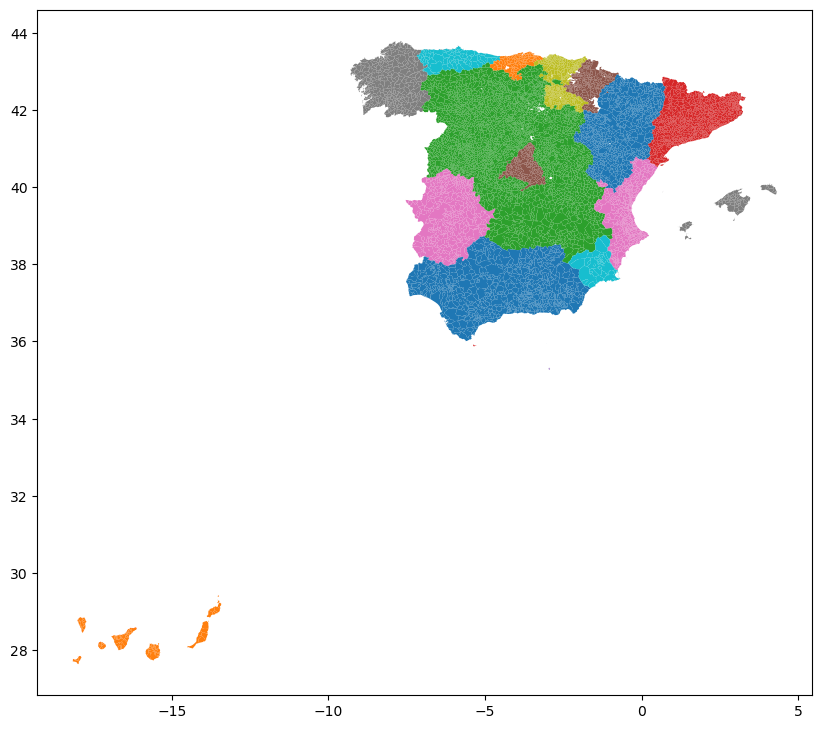

<Axes: >

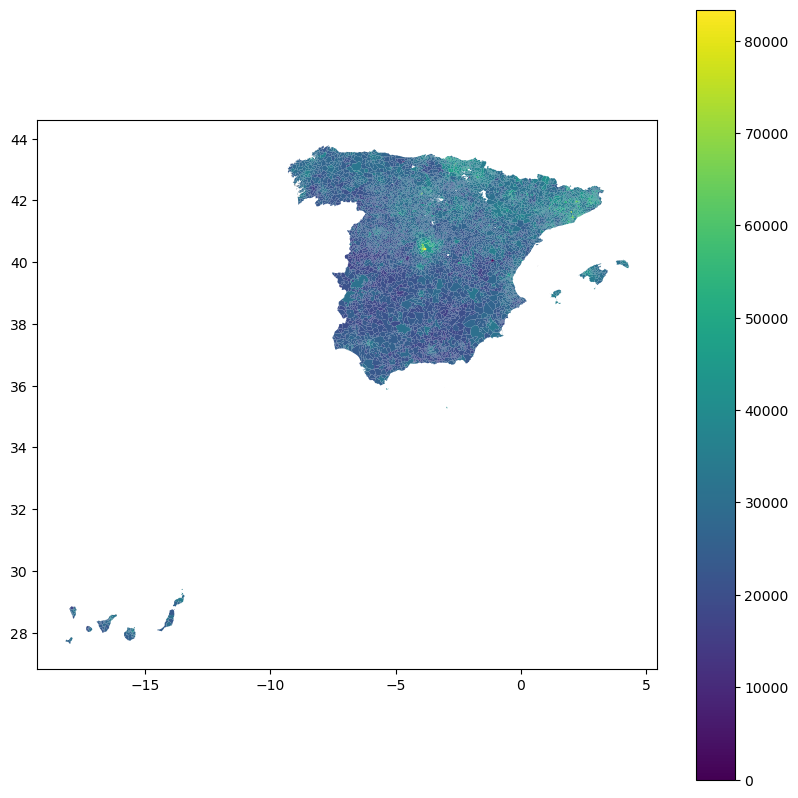

In [44]:
import matplotlib.pyplot as plt

# Basic plot
gdf.plot(column='ccaa', figsize=(10, 10))
plt.show()

# Colored by a column (Choropleth)
gdf.plot(column='rta_nt_med', legend=True, figsize=(10, 10))